In [1]:
import numpy as np
from IPython.display import Image, display
from sedona.spark import SedonaContext
import itertools
import os

In [2]:
%%capture
bucket_name = os.environ.get("SEDONA_SOURCE_BUCKET", "apache-sedona-book")

config = SedonaContext.builder()

sedona = SedonaContext.create(config.getOrCreate())

sedona.sparkContext.setLogLevel("ERROR")

sc = sedona.sparkContext
sedona.sparkContext.setCheckpointDir("checkpoint")

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/11/30 20:41:27 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
25/11/30 20:41:29 WARN UDTRegistration: Cannot register UDT for org.geotools.coverage.grid.GridCoverage2D, which is already registered.
25/11/30 20:41:29 WARN SimpleFunctionRegistry: The function rs_union_aggr replaced a previously registered function.
25/11/30 20:41:29 WARN UDTRegistration: Cannot register UDT for org.locationtech.jts.geom.Geometry, which is already registered.
25/11/30 20:41:29 WARN UDTRegistration: Cannot register UDT for org.apache.sedona.common.S2Geography.Geography, which is already registered.
25/11/30 20:41:29 WARN UDTRegistration: Cannot register UDT for org.locationtech.jts.index.SpatialIndex, which is already registered.
25/11/30 20:41:29 WARN SimpleFunctionRegistry: The function st_envelop

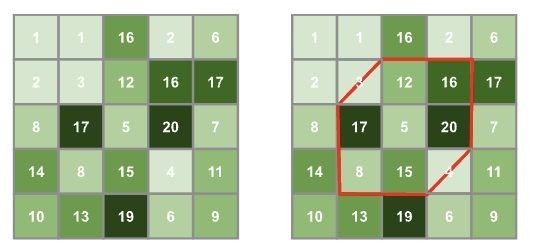

In [3]:
display(Image(filename='images/zonal-statistics.png'))

In [4]:
input_raster = [
    [1, 1, 16, 2, 6],
    [2, 3, 12, 16, 17],
    [8, 17, 5, 20, 7],
    [14, 8, 15, 4, 11],
    [10, 13, 19, 6, 9]
]

input_raster_with_no_data = [
    [1, 1, 16, 2, 6],
    [2, 3, None, 16, 17],
    [8, None, 5, 20, 7],
    [14, 8, 15, 4, 11],
    [10, 13, 19, 6, 9]
]

geom_wkt = "POLYGON((1 1, 1 3, 2 4, 4 4, 4 2, 3 1, 1 1))"
geom_wkt2 = "POLYGON((0 3, 1 4, 3 5, 4 4, 3 2, 1 1, 0 3))"
geom_wkt_outside = "POLYGON((100 103, 101 104, 103 105, 104 104, 103 102, 101 101, 100 103))"

flatten = list(itertools.chain.from_iterable(input_raster))
flatten_no_data = list(itertools.chain.from_iterable(input_raster_with_no_data))

array_input = ", ".join([str(number) if number else "null" for number in flatten ])
array_input_no_data = ", ".join([str(number) if number else "null" for number in flatten_no_data ])

sedona.sql(
    f"""
    WITH empty_raster AS (
        SELECT RS_MakeEmptyRaster(1, 5, 5, 0.0, 5.0, 1.0, -1.0, 0.0, 0.0, 4326) AS rast
    )
    SELECT 
        RS_MakeRaster(rast, 'D', ARRAY({array_input})) AS rast,
        RS_MakeRaster(rast, 'D', ARRAY({array_input_no_data})) AS rast2,
        ST_SetSRID(ST_GeomFromText("{geom_wkt}"), 4326) AS geom,
        ST_SetSRID(ST_GeomFromText("{geom_wkt2}"), 4326) AS geom2,
        ST_SetSRID(ST_GeomFromText("{geom_wkt_outside}"), 4326) AS geom_outside
    FROM empty_raster
    """
).createOrReplaceTempView("density")

## different statistics

In [5]:
sedona.sql(
    """
        SELECT 
            RS_ZonalStats(rast, geom, "sum") AS sum_value,
            RS_ZonalStats(rast, geom, "count") AS count_value,
            RS_ZonalStats(rast, geom, "mean") AS mean_value,
            RS_ZonalStats(rast, geom, "median") AS median_value,
            RS_ZonalStats(rast, geom, "mode") AS mode_value,
            RS_ZonalStats(rast, geom, "stddev") AS stddev_value,
            RS_ZonalStats(rast, geom, "variance") AS variance_value,
            RS_ZonalStats(rast, geom, "min") AS min_value,
            RS_ZonalStats(rast, geom, "max") AS max_value
        FROM density
    """
).show()

+---------+-----------+-----------------+------------+----------+-----------------+------------------+---------+---------+
|sum_value|count_value|       mean_value|median_value|mode_value|     stddev_value|    variance_value|min_value|max_value|
+---------+-----------+-----------------+------------+----------+-----------------+------------------+---------+---------+
|    100.0|        9.0|11.11111111111111|        12.0|      20.0|6.293735862833069|39.611111111111114|      3.0|     20.0|
+---------+-----------+-----------------+------------+----------+-----------------+------------------+---------+---------+



## all parameters

```SQL
RS_ZonalStats(
    raster: Raster,
    zone: Geometry,
    band: Integer,
    statType: String,
    allTouched: Boolean,
    excludeNoData: Boolean,
    lenient: Boolean
)
```

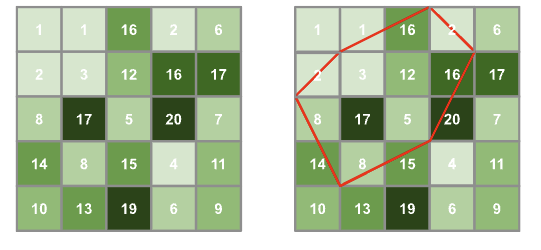

In [6]:
display(Image(filename='images/zonal-statistics-2.png'))

In [7]:
## manipulating allTouched param

In [8]:
sedona.sql(
    """
        SELECT 
            RS_ZonalStats(rast, geom2, 1, "sum", true) AS all_touched,
            RS_ZonalStats(rast, geom2, 1, "sum", false) AS not_all_touched,
            RS_ZonalStats(rast, geom2, 1, "sum") AS default_value
        FROM density
    """
).show()

+-----------+---------------+-------------+
|all_touched|not_all_touched|default_value|
+-----------+---------------+-------------+
|      173.0|           89.0|         89.0|
+-----------+---------------+-------------+



In [9]:
## manipulating excludeNoData param

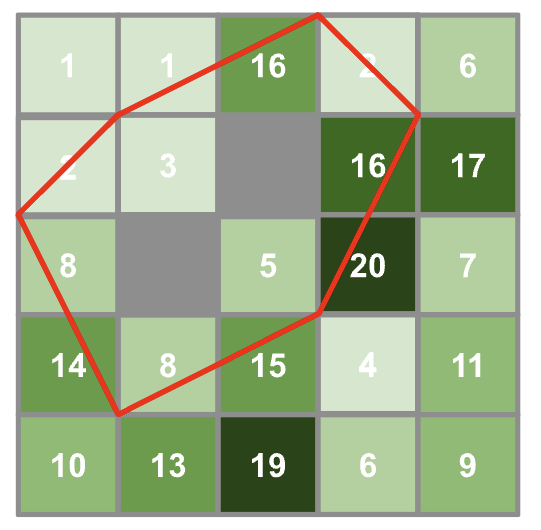

In [10]:
display(Image(filename='images/zonal-statistics-no-data.png'))

In [11]:
sedona.sql(
    """
        SELECT 
            RS_ZonalStats(rast2, geom2, 1, "median", false, true) AS no_data_included,
            RS_ZonalStats(rast2, geom2, 1, "median", false, false) AS no_data_excluded
        FROM density
    """
).show()

+----------------+----------------+
|no_data_included|no_data_excluded|
+----------------+----------------+
|             4.0|             4.0|
+----------------+----------------+



In [12]:
## manipulating lanient

In [13]:
sedona.sql(
    """
        SELECT 
            RS_ZonalStats(rast2, geom_outside, 1, "median", false, false, true) AS lanient_turn_on
        FROM density
    """
).show()

+---------------+
|lanient_turn_on|
+---------------+
|           NULL|
+---------------+



In [14]:
# this one is erroring
# sedona.sql(
#     """
#         SELECT 
#             RS_ZonalStats(rast2, geom_outside, 1, "median", false, false, false) AS lanient_turn_off
#         FROM density
#     """
# ).show()

## RS_ZonalStatsAll

In [15]:
sedona.sql(
    """
        SELECT 
            RS_ZonalStatsAll(rast, geom) AS all_stats
        FROM density
    """
).show(1, False)

+---------------------------------------------------------------------------------------------+
|all_stats                                                                                    |
+---------------------------------------------------------------------------------------------+
|{9.0, 100.0, 11.11111111111111, 12.0, 20.0, 6.293735862833069, 39.611111111111114, 3.0, 20.0}|
+---------------------------------------------------------------------------------------------+



In [16]:
sedona.sql(
    """
        SELECT 
            RS_ZonalStatsAll(rast, geom) AS all_stats
        FROM density
    """
).printSchema()

root
 |-- all_stats: struct (nullable = true)
 |    |-- count: double (nullable = false)
 |    |-- sum: double (nullable = false)
 |    |-- mean: double (nullable = false)
 |    |-- median: double (nullable = false)
 |    |-- mode: double (nullable = false)
 |    |-- stddev: double (nullable = false)
 |    |-- variance: double (nullable = false)
 |    |-- min: double (nullable = false)
 |    |-- max: double (nullable = false)



In [17]:
sedona.sql(
    """
        WITH zonal_all AS (
            SELECT 
                RS_ZonalStatsAll(rast, geom) AS stats
            FROM density
        )
        SELECT stats.* FROM zonal_all

    """
).show()

+-----+-----+-----------------+------+----+-----------------+------------------+---+----+
|count|  sum|             mean|median|mode|           stddev|          variance|min| max|
+-----+-----+-----------------+------+----+-----------------+------------------+---+----+
|  9.0|100.0|11.11111111111111|  12.0|20.0|6.293735862833069|39.611111111111114|3.0|20.0|
+-----+-----+-----------------+------+----+-----------------+------------------+---+----+



In [18]:
sedona.sql(
    """
        WITH zonal_all AS (
            SELECT 
                RS_ZonalStatsAll(rast, geom) AS stats
            FROM density
        ),
        all AS (
            SELECT stats.* FROM zonal_all
        )
        SELECT 
            ROUND(count, 2) AS count,
            ROUND(sum, 2) AS sum,
            ROUND(mean, 2) AS mean,
            ROUND(median, 2) AS median,
            ROUND(mode, 2) AS mode,
            ROUND(stddev, 2) AS stddev,
            ROUND(variance, 2) AS variance,
            ROUND(min, 2) AS min,
            ROUND(max, 2) AS max
        FROM all

    """
).show()

+-----+-----+-----+------+----+------+--------+---+----+
|count|  sum| mean|median|mode|stddev|variance|min| max|
+-----+-----+-----+------+----+------+--------+---+----+
|  9.0|100.0|11.11|  12.0|20.0|  6.29|   39.61|3.0|20.0|
+-----+-----+-----+------+----+------+--------+---+----+



## Example

In [19]:
from sedona.maps.SedonaKepler import SedonaKepler
from shapely.wkt import loads

extent = "POLYGON ((-74.032 40.697, -74.032 40.813, -73.917 40.813, -73.917 40.697, -74.032 40.697))"
extent_df = sedona.createDataFrame([{"geom": loads(extent)}])

/tmp/ipykernel_327/2999806402.py:1: DeprecationWarning: The 'sedona.maps' module is deprecated and will be removed in future versions. Please use 'sedona.spark.maps' instead.
  from sedona.maps.SedonaKepler import SedonaKepler


In [20]:
SedonaKepler.create_map(extent_df, "map")

/usr/local/lib/python3.10/dist-packages/keplergl/keplergl.py:13: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_string


KeplerGl(data={'map': {'index': [0], 'columns': ['geometry'], 'data': [['POLYGON ((-74.0319999999999965 40.697…

In [21]:
(sedona
    .read
    .format("csv")
    .option("header", "true")
    .load(f"s3a://{bucket_name}/source_data/ny_redfin_sold_offers/ny_redfin_sold_offers.csv")
    .selectExpr(
        "CONCAT(ADDRESS, ', ', CITY, ', ', `STATE OR PROVINCE`, ', ', `ZIP OR POSTAL CODE`) AS address_full",
        "ST_Point(CAST(LONGITUDE AS DOUBLE), CAST(LATITUDE AS DOUBLE)) AS geom"
    )
    .where(f"ST_Intersects(geom, ST_GeomFromText('{extent}'))")
    .selectExpr("HASH(address_full) AS id", "ST_TRANSFORM(geom, 'EPSG:4326', 'EPSG:102039') AS geom")
    .where("geom is not null")
    .createOrReplaceTempView("properties"))

In [22]:
(
sedona
    .read
    .format("binaryFile")
    .load(f"s3a://{bucket_name}/source_data/ny_rail_road_and_aviation_noise")
    .selectExpr(
        "RS_SetBandNoDataValue(RS_SetSRID(RS_FromGeoTiff(content), 102039), 1, -3.40282e+38) AS rast",
        f"""ST_Transform(ST_GeomFromText('{extent}'), "epsg:4326", "epsg:102039") AS clip"""
    )
    # to make sure each point is not intersecting with one or more raster tiles, we use 1024x1024
    .selectExpr("EXPLODE(RS_Tile(rast, 1024, 1024)) AS rast", "clip")
    .selectExpr("RS_Clip(rast, 1, clip) AS rast")
    .selectExpr("RS_SetBandNoDataValue(RS_MapAlgebra(rast, 'D', 'out = rast[0] < 0 ? -999 : rast[0];'), -999) AS rast")
    .where("rast is not null")
).createOrReplaceTempView("noise")

In [23]:
sedona.sql(
    """
    SELECT 
        id,
        ST_Buffer(geom, 20) AS geom,
        "20" AS buffer 
    FROM properties
    UNION ALL
    SELECT 
        id,
        ST_Buffer(geom, 50) AS geom,
        "50" AS buffer 
    FROM properties
    UNION ALL
    SELECT 
        id,
        ST_Buffer(geom, 100) AS geom,
        "100" AS buffer 
    FROM properties
    """
).createOrReplaceTempView("properties_buffers")

In [24]:
sedona.sql(
    """
    SELECT
        p.id,
        buffer,
        RS_ZonalStats(rast, geom, 1, "median") AS median_value,
        RS_ZonalStats(rast, geom, 1, "stddev") AS stddev_value,
        RS_ZonalStats(rast, geom, 1, "min") AS min_value,
        RS_ZonalStats(rast, geom, 1, "max") AS max_value,
        geom
    FROM properties_buffers AS p, noise
    WHERE RS_Intersects(rast, geom)
    """
).createOrReplaceTempView("statistics")

In [25]:
sedona.sql(
    """
    SELECT
        id,
        buffer,
        ROUND(median_value, 2) AS median_value,
        ROUND(stddev_value, 2) AS stddev_value,
        ROUND(min_value, 2) AS min_value,
        ROUND(max_value, 2) AS max_value
    FROM statistics
    ORDER BY min_value ASC NULLS LAST, stddev_value ASC
    """
).where("id in ('-219883926', '1687435128')").limit(5).show()

[Stage 13:===================================================>     (9 + 1) / 10]

+----------+------+------------+------------+---------+---------+
|        id|buffer|median_value|stddev_value|min_value|max_value|
+----------+------+------------+------------+---------+---------+
|1687435128|   100|       49.86|        6.05|    45.06|    63.68|
|-219883926|    50|       50.32|         3.4|    45.44|    53.35|
|-219883926|   100|       50.32|         4.1|    45.44|    58.51|
|-219883926|    20|       48.55|        2.49|    46.79|    50.32|
|1687435128|    50|       55.98|        5.95|    47.16|    63.68|
+----------+------+------------+------------+---------+---------+



In [26]:
df = sedona.sql(
    """
    SELECT
        id,
        buffer,
        ROUND(median_value, 2) AS median_value,
        ROUND(stddev_value, 2) AS stddev_value,
        ROUND(min_value, 2) AS min_value,
        ROUND(max_value, 2) AS max_value,
        ST_Transform(geom, 'EPSG:4326')
    FROM statistics
    ORDER BY min_value ASC NULLS LAST, stddev_value ASC
    """
)

In [27]:
from sedona.spark import SedonaKepler
import json

with open("zone_stats_config.json") as f:
    zone_config = json.load(f)

m = SedonaKepler.create_map(df, "map", config=zone_config)

/usr/local/lib/python3.10/dist-packages/jupyter_client/session.py:721: UserWarning: Message serialization failed with:
Out of range float values are not JSON compliant
Supporting this message is deprecated in jupyter-client 7, please make sure your message is JSON-compliant
  content = self.pack(content)


In [28]:
m

KeplerGl(config={'version': 'v1', 'config': {'visState': {'filters': [], 'layers': [{'id': '4zx0wy', 'type': '…